# Análisis de Retención y Estrategias para la Mitigación del Churn: Caso TelecomX 📉

# Introducción

En el siguiente informe se presenta un análisis de datos detallado sobre la fuga de clientes (Churn) en una empresa de telecomunicaciones denominada TelecomX. El objetivo principal es identificar patrones que permitan predecir qué clientes tienen mayor probabilidad de abandonar la compañía.

El documento registra el proceso técnico de limpieza y transformación de información, donde se normalizan archivos JSON para estructurar variables demográficas, contractuales y de servicios.

Mediante el uso de herramientas estadísticas y visualizaciones en Python, se examinan factores clave como la antigüedad del usuario, el tipo de contrato y los métodos de pago.

#📌 Extracción

En esta etapa inicial, se procede a la obtención de los activos de información necesarios para el análisis. Los datos de la compañía TelecomX se encuentran alojados en un repositorio externo en formato JSON, lo cual es común en entornos que manejan estructuras de datos semiestructuradas.

In [1]:
# CONFIGURACIÓN DEL ENTORNO
# Para garantizar la reproducibilidad y eficiencia del análisis, se han
# centralizado las siguientes bibliotecas especializadas al inicio del proyecto:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Origen de los datos:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
df = pd.read_json(url)

In [4]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
# La carga inicial del conjunto de datos revela un total de 7,267 registros:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


El primer vistazo con df.info() muestra que todas las columnas iniciales son de tipo object, lo que justifica la necesidad de la fase de transformación.

In [6]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

El esquema original consta de 6 columnas principales: customerID, Churn, y cuatro columnas de tipo objeto (customer, phone, internet, account) que almacenan diccionarios anidados con la información detallada del cliente y sus servicios.

Esta estructura anidada representa el primer reto técnico, lo que requiere una fase de normalización para poder realizar el análisis estadístico y la visualización.

#🔧 Transformación

El objetivo principal de esta fase es convertir los datos en un formato limpio y listo para el análisis estadístico, corrigiendo inconsistencias técnicas detectadas en la carga inicial.

In [7]:
# Normalizar/Aplanar las columnas que tienen diccionarios
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [8]:
# Concatenar todo en un solo DataFrame
df_TelecomX = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

df_TelecomX.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
# Se verifican el nuevo listado de columnas
df_TelecomX.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [10]:
df_TelecomX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

## Identificación de variables para el análisis de evasión (Churn)

### 1. Variable objetivo

La variable dependiente del estudio es:

* **Churn**: variable binaria que indica si el cliente abandonó (Sí) o permaneció en la empresa (No).

---


### 2. Clasificación de variables

#### 2.1 Clasificación conceptual (según naturaleza del negocio)

* Identificador único: no contiene información predictiva y será excluido del modelado:

    * customerID

* Variables demográficas: estas variables permiten evaluar si existen patrones de abandono asociados a características sociodemográficas. Potencialmente menos relevantes (hipótesis):
    * gender
    * SeniorCitizen
    * Partner
    * Dependents

* Variables de relación contractual: estas variables capturan el nivel de compromiso contractual. Altamente relevantes (hipótesis):
    * Contract
    * PaperlessBilling
    * PaymentMethod

* Servicios contratados: permiten analizar si la diversificación de servicios incrementa la retención mediante mayores costos de cambio. Medianamente relevantes (hipótesis):
    * PhoneService
    * MultipleLines
    * InternetService
    * OnlineSecurity
    * OnlineBackup
    * DeviceProtection
    * TechSupport
    * StreamingTV
    * StreamingMovies

* Variables monetarias y temporales: representan la duración del vínculo y el valor económico generado por el cliente. Permiten analizar cómo el nivel de compromiso (tiempo) y facturación se asocian con la probabilidad de abandono. Altamente relevantes (hipótesis):
    * Tenure
    * Charges.Monthly
    * Charges.Total

#### 2.2 Clasificación técnica (según tipo de tratamiento estadístico)

Con fines de preprocesamiento y modelado, las variables fueron reclasificadas según su estructura de datos y el tipo de transformación requerida:

* Variables binarias (binary_cols): variables con dos categorías posibles, codificadas como 0 y 1 para facilitar el modelado.
    * Churn
    * gender
    * SeniorCitizen
    * Partner
    * Dependents
    * PhoneService
    * PaperlessBilling

* Variables de servicios (service_cols): variables relacionadas con servicios adicionales contratados. Presentan 3 categorías sobre presencia/ausencia del servicio (Yes / No / No service):
    * MultipleLines
    * OnlineSecurity
    * OnlineBackup
    * DeviceProtection
    * TechSupport
    * StreamingTV
    * StreamingMovies

* Variables categóricas multinivel (multi_categ_cols): variables con más de dos categorías que no pueden reducirse sin pérdida de información:
    * InternetService
    * Contract
    * PaymentMethod

* Variables numéricas (numeric_cols): variables cuantitativas utilizadas directamente en el análisis estadístico y modelado:
    * tenure
    * Charges.Monthly
    * Charges.Total

---

### 3. Estrategia metodológica

Para identificar las variables más relevantes se realizará:

* Análisis exploratorio descriptivo.
* Cálculo de tasas de churn por categoría.
* Gráficos demostrativos de la relación de churn con variables.

## Estandarización y transformación de datos

In [11]:
# Variables binarias
binary_cols = ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']

In [12]:
# Variables de servicios (categóricas con 3 niveles)
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

In [13]:
# Variables categóricas multinivel
multi_categ_cols = ['InternetService', 'Contract', 'PaymentMethod']

In [14]:
# Variables numéricas
numeric_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']

In [15]:
# Fución para inspeccionar columnas binarias
def inspeccionar_columna(df, columna, n=20):
    print(f"\nColumna: {columna}")
    print(f"Valores: {df[columna].unique()[:n]}")

In [16]:
for col in binary_cols:
    inspeccionar_columna(df_TelecomX, col)


Columna: Churn
Valores: ['No' 'Yes' '']

Columna: gender
Valores: ['Female' 'Male']

Columna: SeniorCitizen
Valores: [0 1]

Columna: Partner
Valores: ['Yes' 'No']

Columna: Dependents
Valores: ['Yes' 'No']

Columna: PhoneService
Valores: ['Yes' 'No']

Columna: PaperlessBilling
Valores: ['Yes' 'No']


In [17]:
# Asegurar que 'Churn' sea una variable binaria
df_TelecomX['Churn'] = df_TelecomX['Churn'].str.strip()
df_TelecomX['Churn'] = df_TelecomX['Churn'].replace('', np.nan)

In [18]:
# Verificar cuántos registros Nan hay en 'Churn'
# Es posible que se eliminen estos registros Nan en el futuro
df_TelecomX['Churn'].isna().sum()

np.int64(224)

In [19]:
# Crear lista de columnas binarias excluyendo 'gender' para procesarlas por separado
cols_sin_gender = [col for col in binary_cols if col != 'gender']

# Valores categóricos 'Yes'/'No' a formato numérico 1/0
df_TelecomX[cols_sin_gender] = df_TelecomX[cols_sin_gender].replace({'Yes':1, 'No':0})

/tmp/ipykernel_551/2773507026.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_TelecomX[cols_sin_gender] = df_TelecomX[cols_sin_gender].replace({'Yes':1, 'No':0})


In [20]:
# Variable de género a binario: Male (0) y Female (1)
df_TelecomX['gender'] = df_TelecomX['gender'].replace({'Male':0, 'Female':1})

/tmp/ipykernel_551/216432686.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_TelecomX['gender'] = df_TelecomX['gender'].replace({'Male':0, 'Female':1})


In [21]:
# Transformación de 'gender' fue exitosa y ahora es puramente numérica
df_TelecomX['gender'].unique()[:5]

array([1, 0])

In [22]:
df_TelecomX.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
1812,2581-VKIRT,0.0,1,0,1,1,59,1,Yes,DSL,...,Yes,No,Yes,No,No,One year,0,Mailed check,65.50,3801.3
2436,3400-ESFUW,1.0,0,0,1,1,55,1,No,DSL,...,Yes,No,Yes,No,No,Two year,0,Bank transfer (automatic),57.55,3046.4
603,0862-PRCBS,0.0,1,0,1,1,68,1,Yes,Fiber optic,...,Yes,No,Yes,Yes,Yes,Two year,1,Credit card (automatic),103.75,7039.45
342,0495-RVCBF,1.0,1,0,0,0,1,1,No,Fiber optic,...,No,No,No,No,Yes,Month-to-month,1,Electronic check,79.70,79.7
5127,7000-WCEVQ,1.0,1,1,0,0,20,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,1,Mailed check,61.60,1174.35


A continuación se inspeccionan más columnas para comprender su composición.

In [23]:
for col in service_cols:
    inspeccionar_columna(df_TelecomX, col)


Columna: MultipleLines
Valores: ['No' 'Yes' 'No phone service']

Columna: OnlineSecurity
Valores: ['No' 'Yes' 'No internet service']

Columna: OnlineBackup
Valores: ['Yes' 'No' 'No internet service']

Columna: DeviceProtection
Valores: ['No' 'Yes' 'No internet service']

Columna: TechSupport
Valores: ['Yes' 'No' 'No internet service']

Columna: StreamingTV
Valores: ['Yes' 'No' 'No internet service']

Columna: StreamingMovies
Valores: ['No' 'Yes' 'No internet service']


In [24]:
for col in multi_categ_cols:
    inspeccionar_columna(df_TelecomX, col)


Columna: InternetService
Valores: ['DSL' 'Fiber optic' 'No']

Columna: Contract
Valores: ['One year' 'Month-to-month' 'Two year']

Columna: PaymentMethod
Valores: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [25]:
for col in numeric_cols:
    inspeccionar_columna(df_TelecomX, col)


Columna: tenure
Valores: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69]

Columna: Charges.Monthly
Valores: [ 65.6   59.9   73.9   98.    83.9   69.4  109.7   84.65  48.2   90.45
  45.2  116.8   68.95 101.3   45.05  95.75  61.25  72.1   62.7   25.1 ]

Columna: Charges.Total
Valores: ['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9' '2460.55' '8456.75' '351.5' '7261.25' '2560.1' '6849.4'
 '1993.2' '72.1' '2791.5' '25.1']


## Comprobación de incoherencias en los datos

### Valores ausentes

In [26]:
df_TelecomX.isna().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


"Aparentemente" no hay valores ausentes (realmente si los hay). Es posible que clientes nuevos no tengan cargos aún.


In [27]:
df_TelecomX.loc[df_TelecomX['tenure'] == 0, ['customerID', 'Charges.Total', 'Charges.Monthly', 'tenure']]

,customerID,Charges.Total,Charges.Monthly,tenure
975,1371-DWPAZ,,56.05,0
1775,2520-SGTTA,,20.00,0
1955,2775-SEFEE,,61.90,0
2075,2923-ARZLG,,19.70,0
2232,3115-CZMZD,,20.25,0
2308,3213-VVOLG,,25.35,0
2930,4075-WKNIU,,73.35,0
3134,4367-NUYAO,,25.75,0
3203,4472-LVYGI,,52.55,0
4169,5709-LVOEQ,,80.85,0


In [28]:
df_TelecomX[df_TelecomX['tenure'] == 0].shape[0]

11

En este nivel, un hallazgo importante ha sido la dentificación de inconsistencias en 'Charges.Total'. Al filtrar clientes con tenure = 0, observamos que 'Charges.Total' aparece vacío (espacios en blanco). Esto ocurre porque son clientes que acaban de contratar el servicio y aún no han completado su primer ciclo de facturación.

In [29]:
charges_total_modif = df_TelecomX.loc[df_TelecomX['tenure'] == 0, ['Charges.Monthly', 'Charges.Total']]

In [30]:
# El primer bloque muestra que Charges.Total es un object (texto), mientras que los mensuales son float64 (números).
# Esto es una alerta roja en análisis de datos.
charges_total_modif.dtypes

,0
Charges.Monthly,float64
Charges.Total,object


In [31]:
df_TelecomX['Charges.Total'].unique()[:20]

array(['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45',
       '7904.25', '5377.8', '340.35', '5957.9', '2460.55', '8456.75',
       '351.5', '7261.25', '2560.1', '6849.4', '1993.2', '72.1', '2791.5',
       '25.1'], dtype=object)

In [32]:
# Demuestra que en las filas donde la permanencia es 0, el valor no es un número, sino un str.
type(df_TelecomX.loc[df_TelecomX['tenure'] == 0, 'Charges.Total'].iloc[0])

str

In [33]:
# Se identificó que la columna Charges.Total fue importada como tipo object (texto)
# debido a la presencia de espacios en blanco o de cadenas vacías.
df_TelecomX['Charges.Total'].apply(lambda x: repr(x)).loc[df_TelecomX['tenure'] == 0]

,Charges.Total
975,' '
1775,' '
1955,' '
2075,' '
2232,' '
2308,' '
2930,' '
3134,' '
3203,' '
4169,' '


In [34]:
# Se transforma 'Charges.Total' a tipo numérico. El parámetro errors='coerce'
df_TelecomX['Charges.Total'] = pd.to_numeric(df_TelecomX['Charges.Total'], errors='coerce')

In [35]:
# Se convierten los espacios en blanco (strings no válidos) en valores NaN (nulos),
# permitiendo así realizar cálculos matemáticos en la columna.
df_TelecomX['Charges.Total'].apply(lambda x: repr(x)).loc[df_TelecomX['tenure'] == 0]

,Charges.Total
975,nan
1775,nan
1955,nan
2075,nan
2232,nan
2308,nan
2930,nan
3134,nan
3203,nan
4169,nan


In [36]:
df_TelecomX['Charges.Total'].dtype

dtype('float64')

In [37]:
# Se modifican los nombres de columnas para facilitar análisis
df_TelecomX.columns = [
    ''.join(word[0].upper() + word[1:] for word in col.replace('.', ' ').split())
    for col in df_TelecomX.columns
]

In [38]:
# Se crea, por petición del cliente, una columna para 'CuentasDiarias'
df_TelecomX['CuentasDiarias'] = (df_TelecomX['ChargesMonthly'] / 30).round(2)

In [39]:
# Configurar para que muestre todas las columnas
pd.set_option('display.max_columns', None)

# Ver 10 registros aleatorios para evaluar con simple observación inconsistencia
df_TelecomX.head(10)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,CuentasDiarias
0,0002-ORFBO,0.0,1,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0.0,0,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1.0,0,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1.0,0,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1.0,1,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.80
5,0013-MHZWF,0.0,1,0,0,1,9,1,No,DSL,No,No,No,Yes,Yes,Yes,Month-to-month,1,Credit card (automatic),69.40,571.45,2.31
6,0013-SMEOE,0.0,1,1,1,0,71,1,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),109.70,7904.25,3.66
7,0014-BMAQU,0.0,0,0,1,0,63,1,Yes,Fiber optic,Yes,No,No,Yes,No,No,Two year,1,Credit card (automatic),84.65,5377.80,2.82
8,0015-UOCOJ,0.0,1,1,0,0,7,1,No,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,48.20,340.35,1.61
9,0016-QLJIS,0.0,1,0,1,1,65,1,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Mailed check,90.45,5957.90,3.02


Con la ejecución de esta etapa, el conjunto de datos de TelecomX ha sido completamente transformado de una estructura JSON anidada a un formato tabular de 21 columnas enriquecidas. Se han resuelto inconsistencias críticas, como la corrección de tipos de datos en la facturación total y la codificación numérica de variables categóricas para facilitar el procesamiento estadístico. Además, la creación de la métrica 'CuentasDiarias' proporciona una nueva dimensión de análisis sobre el gasto del cliente. Con una base de datos limpia y estandarizada, se procede ahora a la fase de Carga y Análisis (EDA) para dar respuesta a las preguntas de negocio planteadas.

#📊 Carga y análisis

In [40]:
df_TelecomX.describe(include='all')

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,CuentasDiarias
count,7267,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,3,3,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3495,3198,3608,3182,3195,3582,2896,2870,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.265370,0.494289,0.162653,0.484106,0.300124,32.346498,0.902711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.593230,NaN,64.720098,2280.634213,2.157292
std,NaN,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.491265,NaN,30.129572,2268.632997,1.004407
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.610000
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.425000,400.225000,1.180000
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.300000,1391.000000,2.340000
75%,NaN,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.875000,3785.300000,2.995000


In [41]:
df = df_TelecomX.dropna(subset=['Churn'])

In [42]:
df_TelecomX['Churn'].isna().sum()

np.int64(224)

In [43]:
df['Churn'].isna().sum()

np.int64(0)

## Proporción numérica de Churn

In [44]:
proportion_churn = df['Churn'].value_counts(normalize=True).round(4) * 100

In [45]:
count_churn = df['Churn'].value_counts()

In [46]:
dist_proportion_count_churn = pd.DataFrame({
    'Proportion %': proportion_churn,
    'Count': count_churn
})
dist_proportion_count_churn.rename(index = {0.0: 'No', 1.0: 'Yes'}, inplace=True)
dist_proportion_count_churn.rename_axis('Churn', inplace= True)
dist_proportion_count_churn

,Proportion %,Count
Churn,,
No,73.46,5174
Yes,26.54,1869


### Graficar distribución de la variable Churn

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

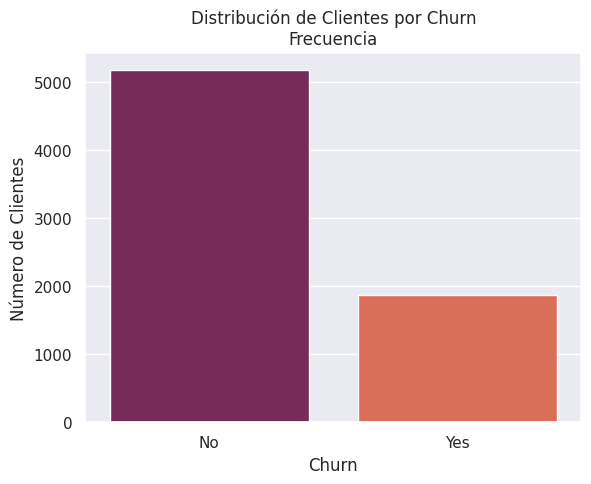

In [48]:
ax = sns.barplot(
    x=dist_proportion_count_churn.index,
    y='Count',
    hue=dist_proportion_count_churn.index,
    legend=False,
    data=dist_proportion_count_churn,
    palette='rocket')
ax.set(
    title='Distribución de Clientes por Churn\nFrecuencia',
    xlabel='Churn', ylabel='Número de Clientes')
plt.xticks(
    ticks=[0, 1],
    labels=['No', 'Yes'])
plt.show()

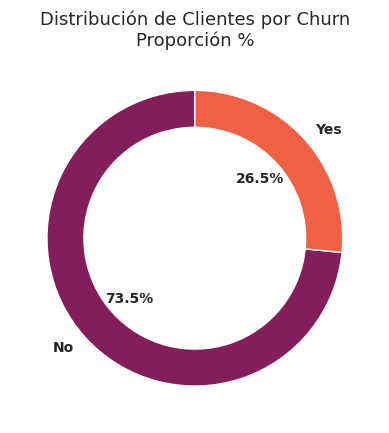

In [49]:
palette = sns.color_palette("rocket", n_colors=len(dist_proportion_count_churn))

fig, ax = plt.subplots()
ax.pie(
    dist_proportion_count_churn['Count'],
    labels=dist_proportion_count_churn.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=90,
    wedgeprops={'width':0.25},
    textprops={'weight':'semibold', 'fontsize':10})
ax.set_title('Distribución de Clientes por Churn\nProporción %',
             loc='center',fontsize=13)

ax.set_aspect('equal')
plt.show()

El análisis inicial de la variable objetivo muestra la proporción de clientes que abandonaron la compañía frente a aquellos que permanecen activos. Como se observa en las visualizaciones, aproximadamente 26.5% de los clientes han cancelado el servicio, mientras que 73.5% continúan siendo clientes de la empresa.

Esta distribución evidencia que, aunque la mayoría de los clientes permanece en la compañía, existe una tasa de abandono significativa, cercana a uno de cada cuatro clientes. Desde una perspectiva de negocio, este nivel de churn representa una oportunidad importante de mejora en las estrategias de retención, lo que justifica la necesidad de identificar los factores que influyen en la decisión de abandono de los clientes.

## Patrones de Churn

### Patrones según características personales.

El objetivo de este análisis es identificar posibles patrones asociados al comportamiento de los clientes desde una perspectiva sociodemográfica. Si bien este tipo de variables no siempre son los factores más determinantes en la decisión de cancelación, su estudio permite detectar segmentos de población con mayor o menor estabilidad dentro de la empresa.

Se calculan las proporciones de churn dentro de cada categoría y se representan mediante gráficos comparativos que permiten visualizar con claridad las diferencias en las tasas de abandono entre los distintos grupos de clientes.

In [50]:
def churn_prop_demographic(df, variable, index_labels=None):
    """
    Calcula y grafica la distribución porcentual de Churn para una variable categórica.

    Parámetros:
    - df: DataFrame
    - variable: nombre de la columna a analizar (string)
    - index_labels: lista opcional para renombrar categorías
    """

    # Tabla de proporciones
    churn_prop = pd.crosstab(df[variable], df['Churn'], normalize='index').round(4) * 100

    # Renombrar columns e index
    churn_prop.columns = ['% No', '% Si']
    churn_prop.index = index_labels

    # Graficar
    ax = churn_prop[['% No', '% Si']].plot(
        kind='bar',
        figsize=(8, 5),
        color=['#841E5A', '#F06043']
    )

    plt.title(f'Distribución de Churn según {variable}')
    plt.ylabel('Porcentaje %')
    plt.xlabel(variable)
    plt.xticks(rotation=0)
    plt.legend(title='¿Abandonó?')
    plt.ylim(0, 100)

    plt.show()

    return

#### Gender

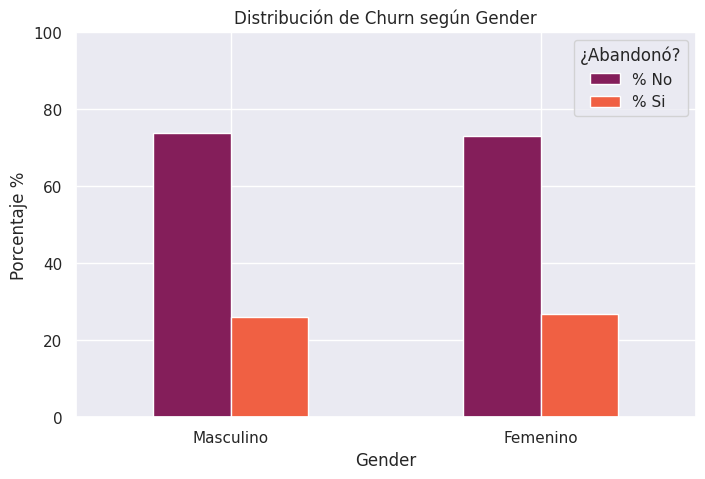

In [51]:
churn_prop_demographic(df, 'Gender', ['Masculino', 'Femenino'])

Los resultados del análisis muestran que el género no presenta una diferencia significativa en la tasa de abandono, ya que tanto hombres como mujeres exhiben proporciones de churn muy similares. Esto sugiere que el comportamiento de cancelación no está influenciado de manera relevante por esta variable.

#### SeniorCitizen

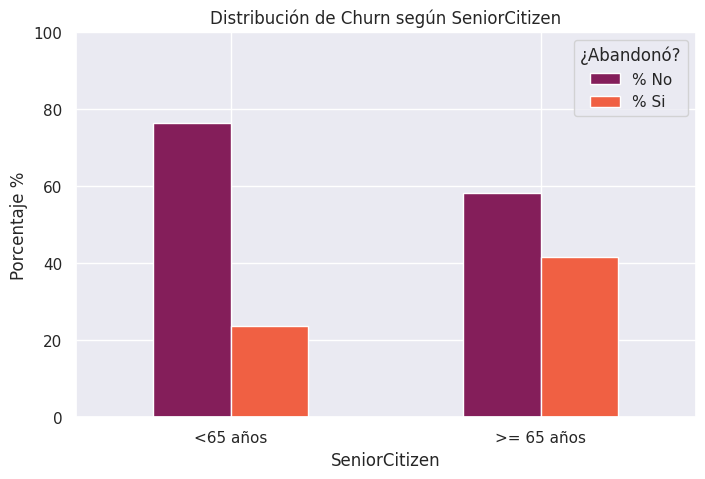

In [52]:
churn_prop_demographic(df, 'SeniorCitizen', ['<65 años', '>= 65 años'])

Se observa que los clientes clasificados como adultos mayores presentan una mayor tasa de churn en comparación con los clientes menores de 65 años. Este patrón podría estar relacionado con factores como sensibilidad al precio, cambios en necesidades de servicio o dificultades en el uso de ciertos servicios digitales.

#### Partner

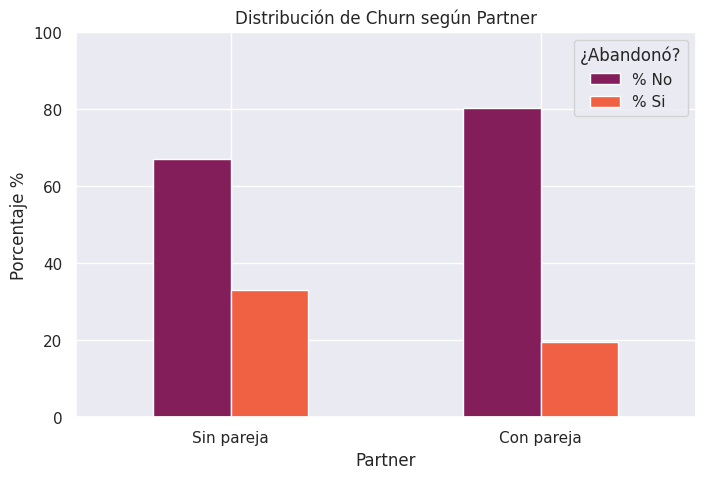

In [53]:
churn_prop_demographic(df, 'Partner', ['Sin pareja', 'Con pareja'])

#### Dependents

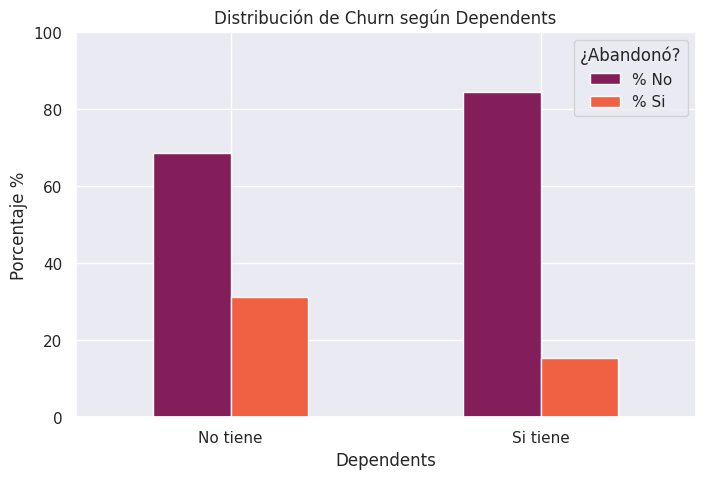

In [54]:
churn_prop_demographic(df, 'Dependents', ['No tiene', 'Si tiene'])

Los clientes sin pareja y sin dependientes muestran mayores niveles de abandono que aquellos que tienen pareja o responsabilidades familiares. Este resultado sugiere que los clientes con estructuras familiares tienden a mantener relaciones más estables con la compañía, posiblemente debido a una mayor dependencia de los servicios contratados dentro del hogar.

En conjunto, estos hallazgos indican que, aunque las variables demográficas no son los principales determinantes del churn, sí contribuyen a identificar perfiles de clientes con diferentes niveles de riesgo de abandono, lo cual puede ser útil para diseñar estrategias de retención más segmentadas.

### Patrones según tipo de contrato y método de pago

En esta sección se examina la relación entre la tasa de abandono de clientes (churn) y variables vinculadas con el compromiso contractual y las condiciones administrativas del servicio. En particular, se analizan el tipo de contrato, la preferencia por facturación electrónica y el método de pago utilizado por los clientes.

Estas variables son especialmente relevantes desde una perspectiva de negocio, ya que reflejan el grado de compromiso que el cliente mantiene con la empresa.

Se calcularon las proporciones de churn dentro de cada categoría y se representaron mediante gráficos comparativos.

In [55]:
def churn_contractual_commitment(df, variable, index_labels=None):
  churn_contractual = pd.crosstab(df[variable], df['Churn'], normalize='index').round(4) * 100
  churn_contractual.columns = ['% No', '% Si']
  churn_contractual.index = index_labels

  ax = churn_contractual.plot(
      kind = 'bar',
      figsize = (8, 5),
      color = ['#841E5A', '#F06043'],
      stacked=True
  )

  plt.title(f'Distribución de Churn según {variable}')
  plt.ylabel('Porcentaje (%) de Churn')
  plt.xlabel(variable)
  plt.xticks(rotation=30)
  plt.ylim(0, 110)
  ax.legend(
      title='¿Abandonó?',
      loc='lower right'
  )

  for container in ax.containers:
      ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10, fontweight='bold', color='white')

  plt.show()

  return

#### Contract

In [56]:
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(4) * 100
churn_contract.columns = ['% No', '% Si']
churn_contract

,% No,% Si
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


* El tipo de contrato es una variable fuertemente asociada al churn.

* A mayor compromiso contractual, menor probabilidad de abandono.

* El contrato mensual ofrece mayor flexibilidad, lo que reduce el costo de cambio y facilita el abandono.

* Contratos anuales o bianuales generan mayor estabilidad en ingresos para la empresa.

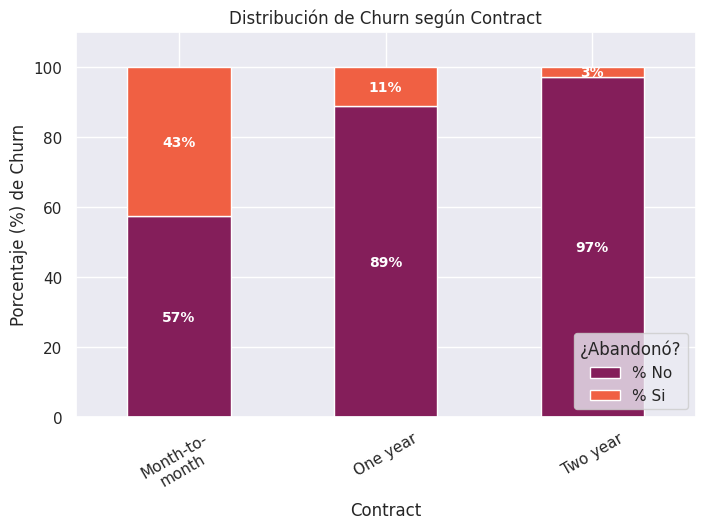

In [57]:
churn_contractual_commitment(df, 'Contract', index_labels=['Month-to-\nmonth', 'One year','Two year' ])


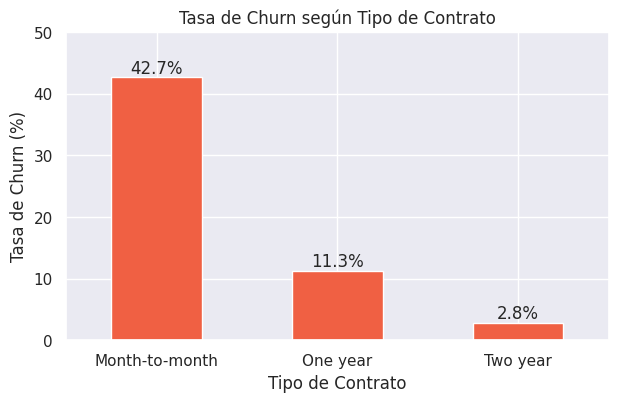

In [58]:
churn_rate = churn_contract['% Si']

ax = churn_rate.plot(
    kind='bar',
    figsize=(7,4),
    color='#F06043'
)

plt.title('Tasa de Churn según Tipo de Contrato')
plt.ylabel('Tasa de Churn (%)')
plt.xlabel('Tipo de Contrato')
plt.xticks(rotation=0)
plt.ylim(0, 50)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.show()

Los resultados muestran que el tipo de contrato es uno de los factores más fuertemente asociados con el churn. Los clientes con contratos mes a mes presentan la tasa de abandono más alta, cercana al 43%, mientras que los contratos de un año reducen significativamente esta tasa y los contratos de dos años muestran niveles de churn muy bajos. Esto sugiere que un mayor compromiso contractual contribuye a aumentar la estabilidad de la relación entre el cliente y la empresa.

####  PaperlessBilling

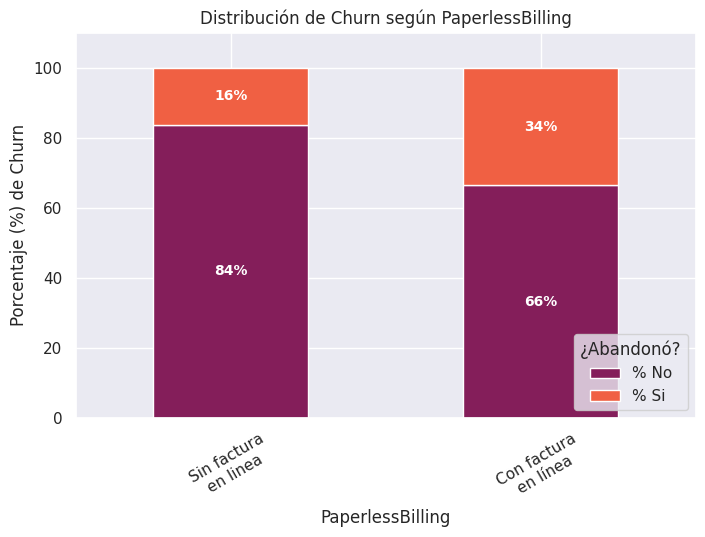

In [59]:
churn_contractual_commitment(df, 'PaperlessBilling', index_labels=['Sin factura\nen linea', 'Con factura\nen línea'])

En relación con la facturación electrónica, se observa que los clientes que utilizan facturación en línea presentan una mayor proporción de churn en comparación con aquellos que reciben facturas tradicionales. Este resultado podría estar asociado a perfiles de clientes más digitales.

#### PaymentMethod

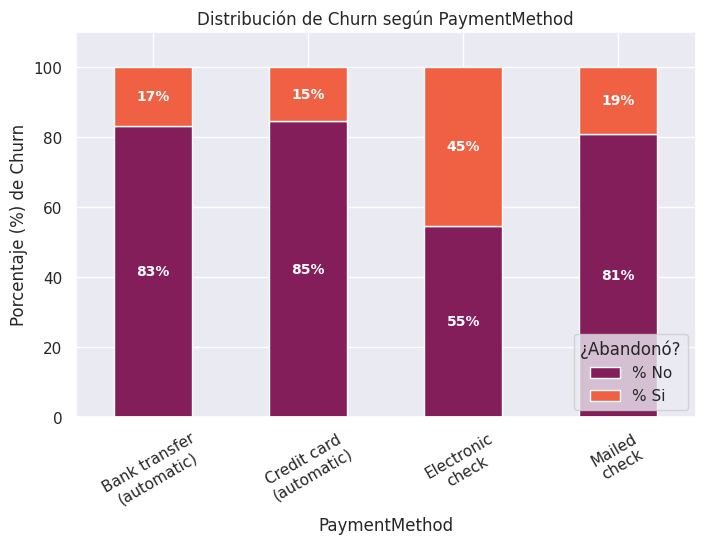

In [60]:
churn_contractual_commitment(df, 'PaymentMethod', index_labels=['Bank transfer\n(automatic)', 'Credit card\n(automatic)', 'Electronic\ncheck', 'Mailed\ncheck'])

Respecto a los métodos de pago, el análisis indica que los clientes que utilizan electronic check presentan las tasas de abandono más elevadas, mientras que los métodos automáticos como transferencias bancarias o pagos con tarjeta de crédito muestran niveles de churn considerablemente menores. Esto podría interpretarse como una señal de mayor estabilidad en los clientes que utilizan sistemas de pago automatizados.

En conjunto, estos resultados sugieren que las variables relacionadas con el compromiso contractual y la forma de pago tienen un impacto significativo en la retención de clientes, lo que abre oportunidades para diseñar estrategias orientadas a incentivar contratos de mayor duración y métodos de pago automáticos.

### Patrones según servicios que aumentan o reducen retención

En esta sección se analiza la relación entre la contratación de servicios adicionales ofrecidos por la compañía y la probabilidad de abandono de los clientes. Estos servicios incluyen funcionalidades complementarias como seguridad en línea, soporte técnico, respaldo de datos, protección de dispositivos y servicios de entretenimiento.

Se calcularon las tasas de churn entre los clientes que contrataron cada servicio y se compararon mediante visualizaciones que permiten identificar cuáles de estos servicios están asociados con menores niveles de abandono.

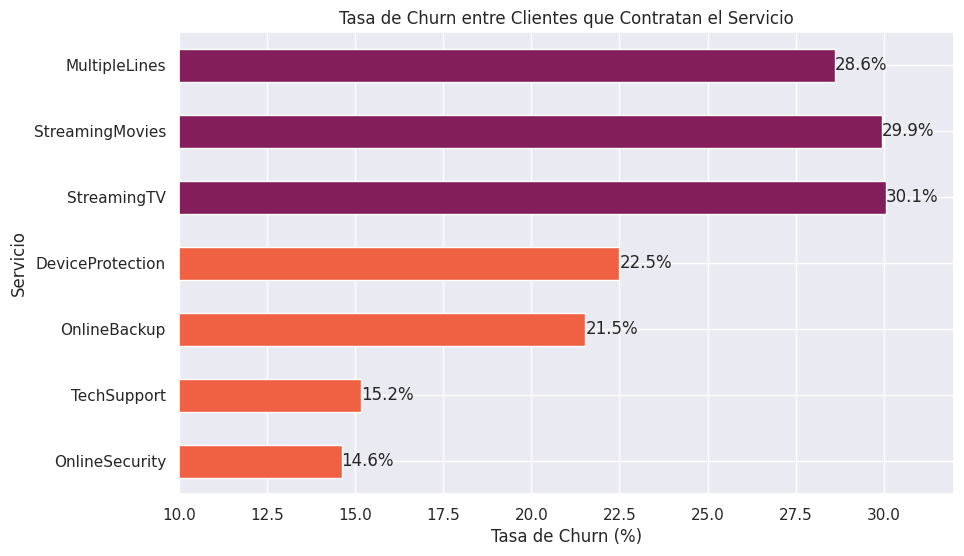

In [61]:
results = []

for col in service_cols:

    ct = pd.crosstab(df[col], df['Churn'])

    if 'Yes' in ct.index:

        total_yes = ct.loc['Yes'].sum()
        churn_yes = ct.loc['Yes', 1.0]

        tasa_churn = (churn_yes / total_yes) * 100

        results.append({
            'Servicio': col,
            'Total Clientes': total_yes,
            'Clientes Churn': churn_yes,
            'Tasa_Churn_%': round(tasa_churn, 2)
        })

services_summary = pd.DataFrame(results)
services_summary = services_summary.sort_values('Clientes Churn', ascending=True)

services_summary = services_summary.set_index('Servicio')

ax = services_summary['Tasa_Churn_%'].plot(
    kind='barh',
    figsize=(10,6),
    color=['#F06043', '#F06043', '#F06043', '#F06043', '#841E5A', '#841E5A', '#841E5A']
)

plt.xlabel('Tasa de Churn (%)')
plt.title('Tasa de Churn entre Clientes que Contratan el Servicio')
plt.xlim(10, 32)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.show()

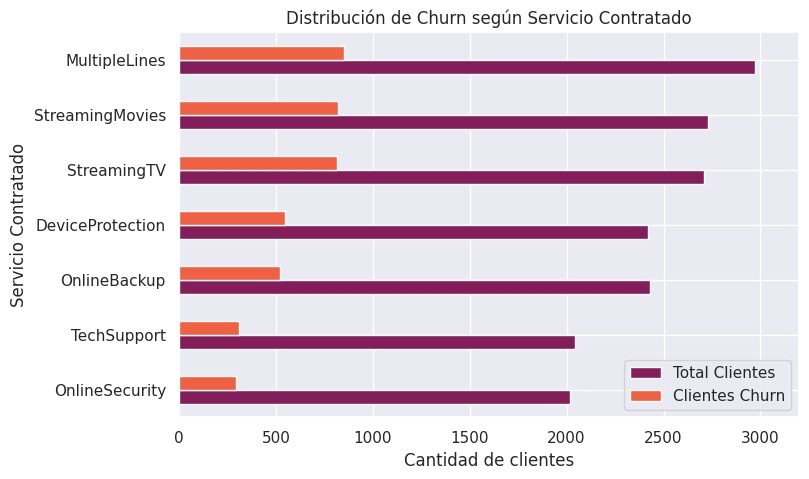

In [62]:
ax = services_summary[['Total Clientes', 'Clientes Churn']].plot(
    kind='barh',
    figsize=(8, 5),
    color=['#841E5A', '#F06043']
)

plt.title('Distribución de Churn según Servicio Contratado')
plt.xlabel('Cantidad de clientes')
plt.ylabel('Servicio Contratado')
plt.xticks(rotation=0)
plt.xlim(0, 3200)

plt.show()

El análisis revela diferencias claras en las tasas de churn entre los distintos servicios adicionales. En particular, los servicios relacionados con seguridad y soporte técnico, como OnlineSecurity y TechSupport, presentan las tasas de abandono más bajas entre los clientes que los contratan. Esto sugiere que estos servicios contribuyen significativamente a la retención, posiblemente porque aumentan la confianza del cliente y mejoran su experiencia con el servicio.

Por otro lado, los servicios de entretenimiento, como StreamingTV y StreamingMovies, así como la opción de MultipleLines, muestran tasas de churn relativamente más altas en comparación con otros servicios. Esto podría indicar que estos servicios, aunque populares, no generan el mismo nivel de compromiso o dependencia con la empresa.

En términos generales, los resultados sugieren que los servicios orientados a soporte, seguridad y respaldo de información tienen un mayor impacto positivo en la retención de clientes.

#### PhoneService

El objetivo de este análisis es evaluar si la presencia o ausencia de este servicio base tiene algún impacto en la decisión de los clientes de continuar o cancelar su suscripción. Para ello, se calculó la proporción de clientes que abandonaron la compañía dentro de cada grupo y se representó mediante gráficos comparativos que permiten observar las diferencias en las tasas de churn.

In [63]:
df['PhoneService'].value_counts()

,count
PhoneService,
1,6361
0,682


In [64]:
churn_phoneservice = pd.crosstab(df['PhoneService'], df['Churn'], normalize='index').round(2) * 100
churn_phoneservice.columns = ['% No Churn', '% Si Churn']
churn_phoneservice.rename(index = {0: 'No Phone Service', 1: 'Yes Phone Service'}, inplace=True)
churn_phoneservice

,% No Churn,% Si Churn
PhoneService,,
No Phone Service,75.0,25.0
Yes Phone Service,73.0,27.0


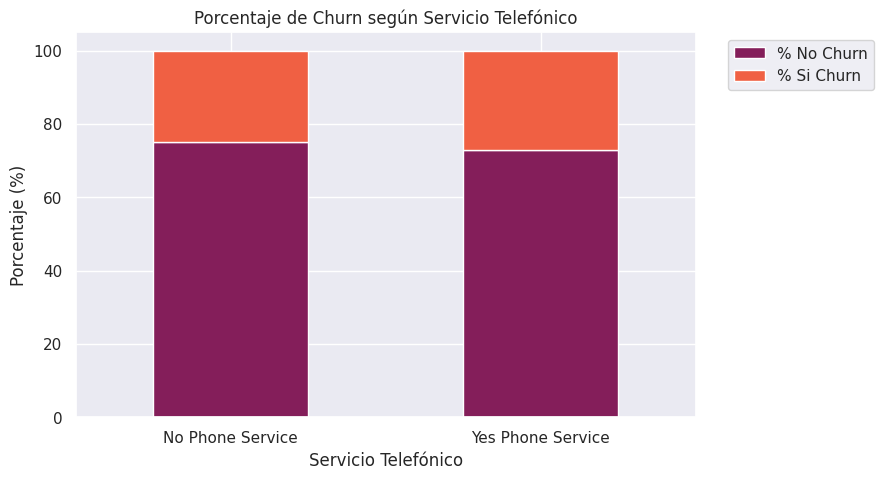

In [65]:
churn_phoneservice.plot(kind='bar',
                        stacked=True,
                        color=['#841E5A', '#F06043'],
                        figsize=(8, 5))

plt.title('Porcentaje de Churn según Servicio Telefónico')
plt.xlabel('Servicio Telefónico')
plt.ylabel('Porcentaje (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.xticks(rotation=0)
plt.show()

Los resultados indican que la presencia del servicio telefónico no parece ser un factor determinante en la decisión de abandono de los clientes. Las tasas de churn observadas entre quienes cuentan con este servicio y quienes no lo tienen son muy similares, lo que sugiere que esta variable no influye significativamente en la retención.

Este comportamiento puede explicarse porque el servicio telefónico forma parte de la oferta básica de la empresa y, por sí solo, no genera un nivel de diferenciación suficiente que afecte la permanencia del cliente.

#### InternetService

Los clientes del conjunto de datos se clasifican en tres categorías según el tipo de servicio contratado: DSL, fibra óptica o ausencia de servicio de internet. Cada una de estas opciones presenta diferentes características en términos de velocidad, costo y experiencia de usuario, lo que podría influir en el nivel de satisfacción y, en consecuencia, en la decisión de permanecer o abandonar la compañía.

In [66]:
churn_internetservice = pd.crosstab(df['InternetService'], df['Churn'], normalize='index').round(2) * 100
churn_internetservice.columns = ['% No Churn', '% Si Churn']
churn_internetservice

,% No Churn,% Si Churn
InternetService,,
DSL,81.0,19.0
Fiber optic,58.0,42.0
No,93.0,7.0


Normalmente:

- Fiber optic → mayor churn

- DSL → churn intermedio

- No internet → menor churn

Y eso tiene lógica:

- Fiber suele ser más caro

- Clientes más exigentes

- Mayor sensibilidad a precio

El análisis muestra diferencias importantes en la tasa de churn según el tipo de servicio de internet. Los clientes que utilizan fibra óptica presentan la mayor proporción de abandono, con una tasa cercana al 42%, considerablemente superior a la observada en los clientes que utilizan DSL, cuyo churn ronda el 19%.

Por otro lado, los clientes que no cuentan con servicio de internet presentan la menor tasa de abandono, cercana al 7%, lo que sugiere una relación más estable con la empresa en este segmento.

Una posible explicación para este comportamiento es que los servicios de fibra óptica suelen implicar mayores costos mensuales y expectativas más altas en términos de calidad del servicio, lo que puede aumentar la sensibilidad del cliente ante problemas de precio o desempeño. En contraste, los clientes con servicios más básicos o con menor dependencia del internet podrían mostrar menor propensión a cambiar de proveedor.

En conjunto, estos resultados indican que el tipo de servicio de internet es un factor relevante en el análisis del churn, especialmente en el caso de la fibra óptica.

In [67]:
churn_internet_contract = pd.crosstab([df['InternetService'], df['Contract']], df['Churn'], normalize='index').round(2) * 100
churn_internet_contract.columns = ['% No Churn', '% Si Churn']
churn_internet_contract

% No Churn  % Si Churn
InternetService Contract                              
DSL             Month-to-month        68.0        32.0
                One year              91.0         9.0
                Two year              98.0         2.0
Fiber optic     Month-to-month        45.0        55.0
                One year              81.0        19.0
                Two year              93.0         7.0
No              Month-to-month        81.0        19.0
                One year              98.0         2.0
                Two year              99.0         1.0

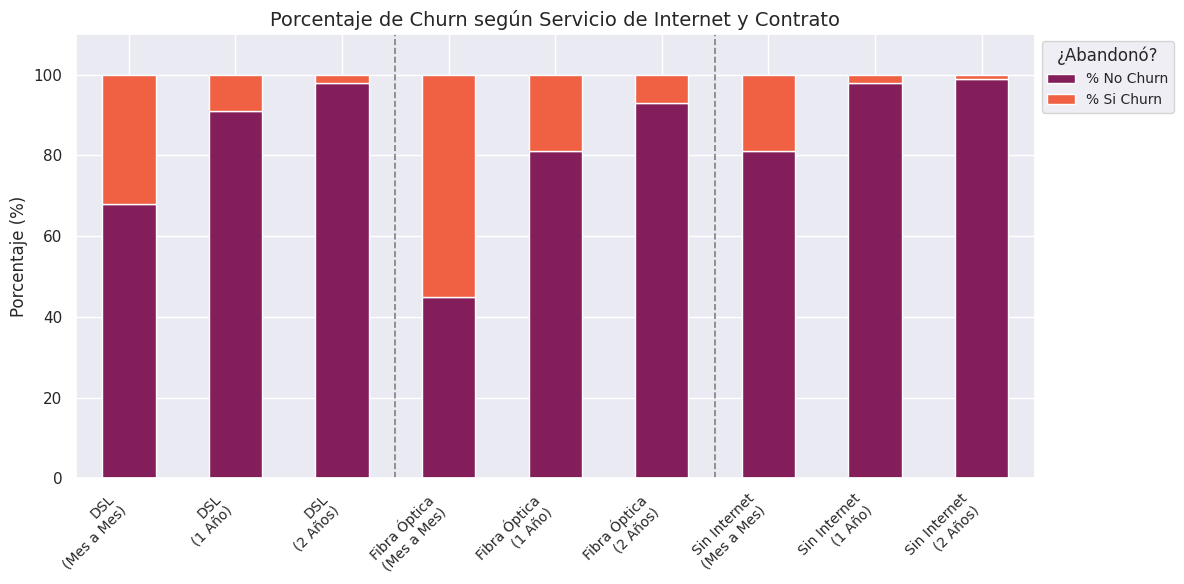

In [68]:
ax = churn_internet_contract.plot(kind='bar',
                        stacked=True,
                        color=['#841E5A', '#F06043'],
                        figsize=(12, 6))

plt.title('Porcentaje de Churn según Servicio de Internet y Contrato', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('')
plt.legend(title='¿Abandonó?', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Mapeo de nombres para etiquetas más limpias
internet_map = {'DSL': 'DSL', 'Fiber optic': 'Fibra Óptica', 'No': 'Sin Internet'}
contract_map = {'Month-to-month': 'Mes a Mes', 'One year': '1 Año', 'Two year': '2 Años'}

# Generar etiquetas personalizadas para el eje X
custom_labels = [f"{internet_map[idx[0]]}\n({contract_map[idx[1]]})" for idx in churn_internet_contract.index]

ax.set_xticks(range(len(churn_internet_contract.index)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)

# Añadir líneas verticales para separar los grupos de InternetService
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1.2) # Después del grupo DSL
ax.axvline(x=5.5, color='gray', linestyle='--', linewidth=1.2) # Después del grupo Fibra Óptica

plt.ylim(0, 110)
plt.tight_layout() # Ajusta el diseño para evitar que las etiquetas se corten
plt.show()

Si bien el tipo de servicio de internet muestra diferencias claras en las tasas de churn, un análisis más detallado revela que este comportamiento también está influenciado por el tipo de contrato asociado al servicio. Al observar la combinación de ambas variables, se identifican variaciones importantes dentro de cada tipo de internet.

En particular, los clientes que utilizan fibra óptica con contratos mensuales (month-to-month) presentan la tasa de abandono más alta de todo el conjunto analizado, superando el 50% de churn. En contraste, cuando el mismo servicio de fibra óptica está asociado a contratos de uno o dos años, la tasa de abandono disminuye considerablemente.

Un patrón similar se observa en el servicio DSL, donde los contratos mensuales presentan niveles de churn significativamente mayores que los contratos de mayor duración. Esto sugiere que el compromiso contractual actúa como un factor moderador del churn, reduciendo la probabilidad de abandono incluso en servicios con mayor riesgo de cancelación.

En conjunto, estos resultados indican que el churn no depende únicamente del tipo de servicio contratado, sino también del nivel de compromiso que el cliente mantiene con la empresa.

### Patrones según la duración y la inversión económica del cliente

#### Tenure vs Churn

En esta sección se analiza la relación entre la antigüedad del cliente en la empresa (Tenure) y la probabilidad de abandono del servicio. La variable Tenure representa el número de meses que un cliente ha permanecido con TelecomX desde el inicio de su contrato.

Desde una perspectiva de negocio, esta variable es particularmente relevante, ya que el tiempo de permanencia suele reflejar el nivel de consolidación de la relación entre el cliente y la empresa.

Hipótesis típica:

Clientes con menor tenure → mayor churn

Clientes antiguos → menor churn

📊 Gráficas para analizar:

Boxplot de Tenure por Churn

Distribución (histogramas separados)

Media y mediana por grupo

📈 Lo que se busca observar:

El riesgo es más alto en los primeros X meses.

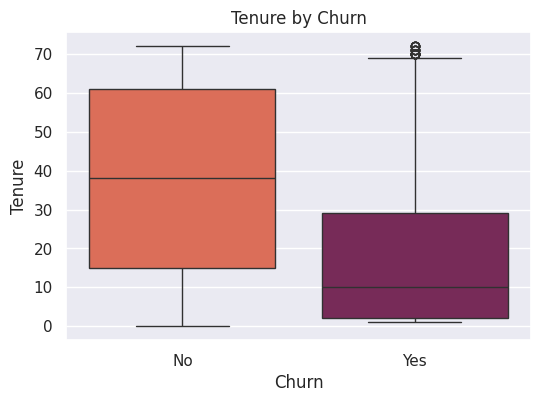

In [69]:
tenure_labels = df['Churn'].map({0:'No', 1:'Yes'})

plt.figure(figsize=(6,4))

sns.boxplot(
    x=tenure_labels,
    y=df['Tenure'],
    hue=tenure_labels,
    palette='rocket_r'
)

plt.title('Tenure by Churn')
plt.show()

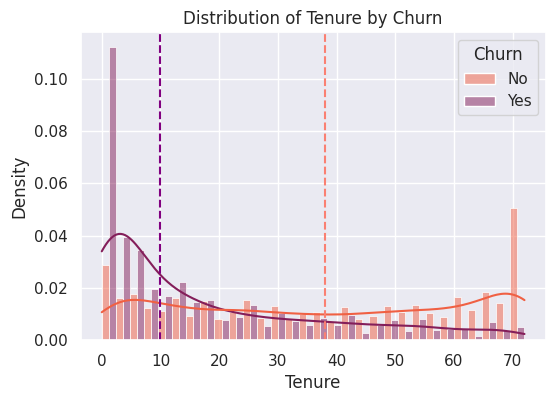

,Tenure
Churn,
0.0,38.0
1.0,10.0


In [70]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='Tenure',
    hue=tenure_labels,
    palette='rocket_r',
    stat='density',
    common_norm=False,
    bins=30,
    alpha=0.5,
    kde=True,
    multiple='dodge'
)

# Calcular medias
medians = df.groupby('Churn')['Tenure'].median()

# Añadir líneas
plt.axvline(medians[0], color='salmon', linestyle='--')
plt.axvline(medians[1], color='purple', linestyle='--')

plt.title('Distribution of Tenure by Churn')
plt.show()
medians

Los resultados muestran una diferencia clara en la antigüedad promedio entre los clientes que permanecen en la empresa y aquellos que han cancelado el servicio. En particular, la mediana de Tenure para los clientes que abandonan la compañía es aproximadamente de 10 meses, mientras que para los clientes que continúan con el servicio la mediana se sitúa alrededor de 38 meses.

Este patrón sugiere que el riesgo de churn es considerablemente mayor durante los primeros meses de relación con la empresa, lo que indica la existencia de un período inicial crítico en el que los clientes son más propensos a cancelar el servicio.

A medida que aumenta la permanencia del cliente, la probabilidad de abandono tiende a disminuir, posiblemente debido a factores como la familiaridad con el servicio, la acumulación de beneficios o la existencia de contratos de mayor duración.

#### Charges Monthly vs Churn

En esta sección se analiza la relación entre el nivel de gasto mensual de los clientes (ChargesMonthly) y la probabilidad de abandono del servicio. Esta variable representa el monto que cada cliente paga mensualmente por los servicios contratados dentro de la plataforma TelecomX.

Desde una perspectiva de negocio, el nivel de facturación puede influir significativamente en la decisión de permanencia del cliente. Por un lado, cargos mensuales más elevados podrían reflejar una mayor cantidad de servicios contratados, lo que potencialmente incrementaría el valor percibido del servicio. Por otro lado, precios más altos también podrían generar mayor sensibilidad al costo y aumentar la probabilidad de cancelación.

📊 Gráficas para analizar:

Boxplot de Charges.Monthly por Churn

KDE / histogramas comparados

Media por grupo

📈 Lo que se busca observar:

Clientes con cargos mensuales altos → ¿más probabilidad de churn?
O clientes con cargos muy bajos → churn porque no están muy comprometidos

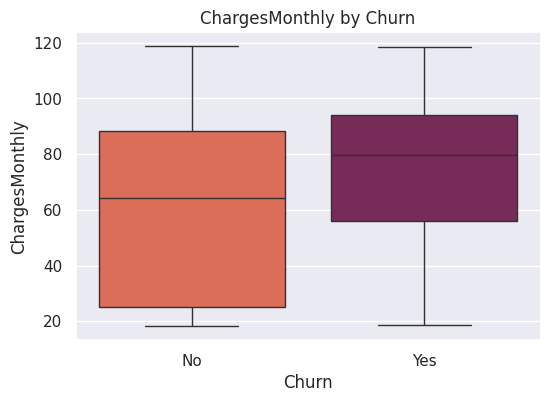

In [71]:
churn_labels = df['Churn'].map({0: 'No', 1: 'Yes'})
plt.figure(figsize=(6,4))
sns.boxplot(
    x=churn_labels,
    y=df['ChargesMonthly'],
    hue=churn_labels,
    palette='rocket_r',
)
plt.title('ChargesMonthly by Churn')
plt.show()

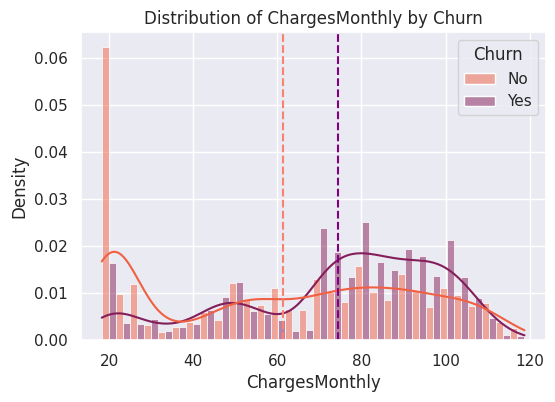

,ChargesMonthly
Churn,
0.0,61.27
1.0,74.44


In [72]:
churn_labels = df['Churn'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='ChargesMonthly',
    hue=churn_labels,
    palette='rocket_r',
    stat='density',      # importante para comparar distribuciones
    common_norm=False,   # normaliza cada grupo por separado
    bins=30,
    alpha=0.5,
    kde=True,
    multiple='dodge'
)

# Calcular medias
means = df.groupby('Churn')['ChargesMonthly'].mean().round(2)

# Añadir líneas
plt.axvline(means[0], color='salmon', linestyle='--')
plt.axvline(means[1], color='purple', linestyle='--')

plt.title('Distribution of ChargesMonthly by Churn')
plt.show()
means

Los resultados muestran que los clientes que abandonan la compañía presentan, en promedio, cargos mensuales más altos que aquellos que permanecen en el servicio. En particular, el gasto promedio mensual de los clientes que continúan con TelecomX es de aproximadamente 61.27, mientras que los clientes que cancelan el servicio presentan un promedio cercano a 74.44.

Este patrón sugiere que los clientes con facturación mensual más elevada tienden a presentar una mayor probabilidad de churn. Una posible explicación es que los usuarios con planes más costosos pueden ser más sensibles al precio o tener mayores expectativas respecto a la calidad del servicio, lo que podría llevarlos a cambiar de proveedor si perciben que el valor recibido no justifica el costo.

Asimismo, este resultado puede estar relacionado con hallazgos observados en análisis anteriores, como el caso de los clientes de fibra óptica, que suelen presentar cargos mensuales más altos y también muestran tasas de abandono más elevadas.

#### Charges Total vs Churn

En esta sección se analiza la relación entre el gasto total acumulado de los clientes (ChargesTotal) y la probabilidad de abandono del servicio.

El análisis de esta variable permite evaluar si los clientes que han realizado una mayor inversión económica en la compañía presentan un comportamiento diferente en términos de permanencia. En muchos casos, un mayor gasto acumulado puede reflejar una relación más prolongada con la empresa, lo que podría asociarse con mayores niveles de fidelización.

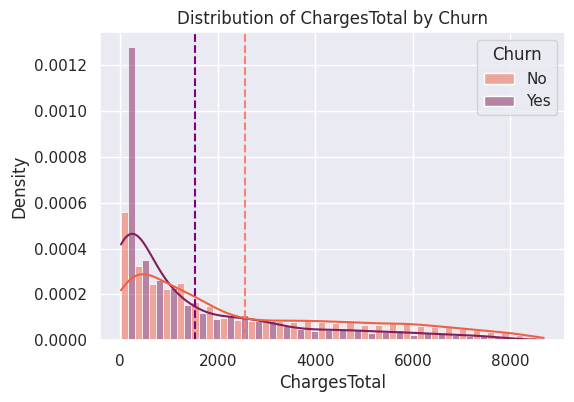

,ChargesTotal
Churn,
0.0,2555.34
1.0,1531.80


In [73]:
churn_labels = df['Churn'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='ChargesTotal',
    hue=churn_labels,
    palette='rocket_r',
    stat='density',      # importante para comparar distribuciones
    common_norm=False,   # normaliza cada grupo por separado
    bins=30,
    alpha=0.5,
    kde=True,
    multiple='dodge'
)

# Calcular medias
means = df.groupby('Churn')['ChargesTotal'].mean().round(2)

# Añadir líneas
plt.axvline(means[0], color='salmon', linestyle='--')
plt.axvline(means[1], color='purple', linestyle='--')

plt.title('Distribution of ChargesTotal by Churn')
plt.show()
means


El boxplot a continuación muestra que los clientes que abandonan la compañía tienden a presentar niveles más bajos de gasto total acumulado, lo que sugiere que el churn ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa. No obstante, la presencia de algunos outliers indica que incluso clientes con alto gasto acumulado pueden llegar a cancelar el servicio, lo que sugiere que otros factores como el tipo de contrato, el precio o la calidad del servicio también pueden influir en la decisión de abandono.

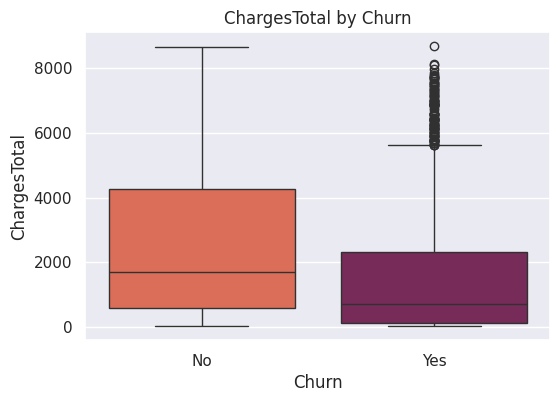

In [74]:
churn_labels = df['Churn'].map({0: 'No', 1: 'Yes'})
plt.figure(figsize=(6,4))
sns.boxplot(
    x=churn_labels,
    y=df['ChargesTotal'],
    hue=churn_labels,
    palette='rocket_r',
)
plt.title('ChargesTotal by Churn')
plt.show()

El análisis muestra que los clientes que permanecen en la empresa tienden a presentar niveles significativamente más altos de gasto total acumulado en comparación con aquellos que abandonan el servicio. Este comportamiento es consistente con el análisis previo de la variable Tenure, ya que los clientes con mayor antigüedad han tenido más tiempo para generar facturación total.

Por el contrario, los clientes que presentan churn suelen tener niveles de gasto total considerablemente menores, lo cual sugiere que el abandono ocurre con mayor frecuencia en etapas relativamente tempranas de la relación con la empresa.

En este sentido, el gasto total no solo refleja el valor económico generado por cada cliente, sino que también funciona como un indicador indirecto de antigüedad y consolidación de la relación comercial. Los clientes con mayor inversión acumulada tienden a mostrar niveles más altos de permanencia, lo que refuerza la importancia de fortalecer la relación con los clientes durante los primeros meses de servicio.

#### Correlación entre variables monetarias y temporales

En esta sección se analiza la relación entre las principales variables numéricas del dataset, particularmente aquellas asociadas con el tiempo de permanencia del cliente y su gasto económico.

El análisis de correlación permite identificar la intensidad y dirección de la relación entre estas variables, lo que contribuye a comprender cómo evolucionan los patrones de facturación a lo largo del tiempo y cómo estos factores pueden estar relacionados con la retención de clientes.

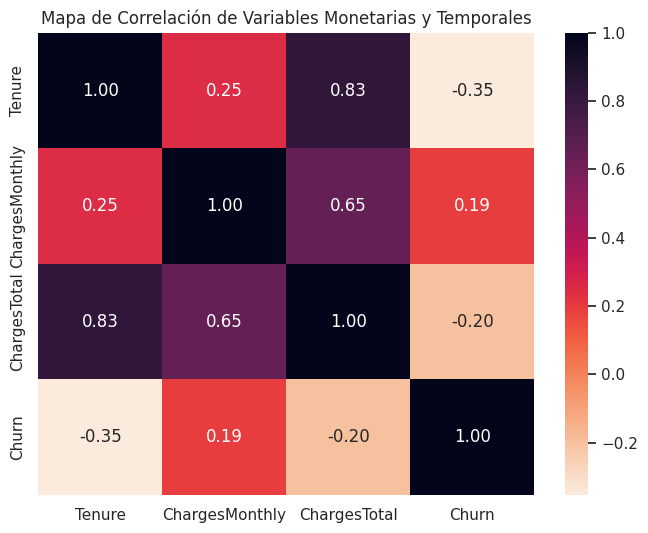

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Tenure', 'ChargesMonthly', 'ChargesTotal', 'Churn']].corr(),
            annot=True,
            cmap='rocket_r',
            fmt=".2f")
plt.title('Mapa de Correlación de Variables Monetarias y Temporales')
plt.show()

En conjunto, el análisis de correlación sugiere que la variable más asociada con el churn es la antigüedad del cliente (Tenure), mostrando una relación negativa moderada con la probabilidad de abandono. Esto indica que los clientes más nuevos presentan un mayor riesgo de cancelar el servicio.

Por otro lado, el gasto mensual muestra una relación positiva débil con el churn, lo que sugiere que los clientes con cargos más altos pueden ser ligeramente más propensos a abandonar el servicio. En contraste, el gasto total acumulado se relaciona negativamente con el churn, lo cual refleja que los clientes con mayor tiempo y mayor inversión en la empresa tienden a permanecer.

Finalmente, las relaciones observadas entre Tenure, ChargesMonthly y ChargesTotal muestran cómo el valor económico del cliente se desarrolla a lo largo del tiempo, reforzando la importancia de retener a los clientes durante las primeras etapas de su relación con la empresa, donde el riesgo de churn es mayor.

#📄Informe final

## 👤 Perfil de mayor riesgo de abandono (Churn)

Basado en el análisis detallado de los datos, el perfil del cliente con mayor riesgo de abandono (Churn) en TelecomX se caracteriza por una combinación de factores contractuales, tecnológicos y demográficos.
A continuación, detallo las características que definen a este perfil:
1. Perfil Contractual y Administrativo (Los factores más críticos)
Este es el grupo de variables con mayor peso en la decisión de abandono:
  - Tipo de Contrato: El cliente típico que hace churn tiene un contrato "Mes a mes". Este segmento presenta una tasa de abandono muy alta, cercana al 43%, frente a los contratos de largo plazo que muestran niveles mínimos de fuga.
- Método de Pago: Existe una fuerte asociación con el uso de "Electronic check" (cheque electrónico), que registra una tasa de abandono del 45%. En contraste, los clientes con pagos automáticos son mucho más estables.
- Facturación: Prefiere la facturación electrónica (Paperless Billing), segmento donde el churn alcanza el 34%.

2. Perfil Tecnológico y de Servicios
- Servicio de Internet: Paradójicamente, los clientes de Fibra Óptica son los más propensos a irse, con una tasa de churn del 42%.
- Combinación Crítica: El riesgo se dispara por encima del 50% cuando el cliente combina Fibra Óptica con un contrato "Mes a mes".
- Ausencia de Servicios de Valor: El cliente que abandona generalmente no tiene contratados servicios de soporte o seguridad, como OnlineSecurity o TechSupport, los cuales han demostrado reducir significativamente la evasión.

3. Perfil Demográfico
Aunque menos determinantes que los contratos, existen rasgos sociodemográficos claros:
- Edad: Los adultos mayores (Senior Citizens), de 65 años o más, presentan una mayor propensión al churn en comparación con los clientes más jóvenes.
- Estructura Familiar: Clientes sin pareja (Partner: No) y sin dependientes (Dependents: No) muestran niveles de abandono superiores. Esto sugiere que las cuentas vinculadas a hogares familiares tienden a ser más estables.

4. Perfil de Antigüedad (Tenure)
- Periodo Crítico: El cliente que hace churn es mayoritariamente un cliente nuevo. La mediana de antigüedad para quienes abandonan la compañía es de solo 10 meses, mientras que los clientes que permanecen tienen una mediana de 38 meses.

En resumen, el "cliente de alto riesgo" es aquel que tiene menos de un año en la empresa, posee un contrato mensual, paga con cheque electrónico, utiliza fibra óptica y no tiene dependientes ni servicios de seguridad contratados.

## 🧐 Ranking de Factores Críticos de Abandono

A partir del análisis exploratorio realizado, es posible identificar los factores que presentan una mayor asociación con la probabilidad de abandono de los clientes, tal como se presenta a continuación:

1.  Tipo de contrato (Contract)
Es el factor con mayor influencia en la probabilidad de abandono.

Contrato Month-to-month → ~42.7% churn

Contrato One year → ~11.3% churn

Contrato Two year → ~2.8% churn

Los clientes con contratos mensuales presentan una flexibilidad mucho mayor para cancelar el servicio, lo que reduce los costos de cambio y facilita el abandono.

2. Tipo de servicio de Internet (InternetService)

Fiber optic → ~42% churn

DSL → ~19% churn

Sin internet → ~7% churn

Los clientes de fibra óptica presentan mayores tasas de abandono, posiblemente debido a: mayores expectativas de calidad, mayor sensibilidad al precio y mayor comparación con competidores.

3. Método de pago (PaymentMethod)

El método Electronic Check presenta la mayor tasa de abandono en comparación con métodos automáticos.

Clientes que utilizan: Transferencias automáticas y Tarjetas automáticas tienden a mostrar mayor estabilidad y menor churn.

4. Servicios adicionales contratados

Los servicios de seguridad y soporte presentan menor churn entre quienes los contratan:

Servicios que reducen churn: OnlineSecurity, TechSupport y OnlineBackup.

Servicios que no reducen significativamente churn: StreamingTV, StreamingMovies y MultipleLines.

Esto sugiere que los servicios que aportan valor funcional y soporte técnico generan mayor fidelización que los servicios de entretenimiento.

5. Antigüedad del cliente (Tenure)

Existe una relación inversa entre el tiempo del cliente en la empresa y el churn:

Clientes con menor antigüedad → mayor riesgo de abandono

Clientes antiguos → mayor estabilidad

Esto sugiere que los primeros meses son el período más crítico para la retención.

6. Variables demográficas

Variables como: Gender, Partner, Dependents y SeniorCitizen presentan impacto moderado o bajo en comparación con variables contractuales o de servicio.

## 💡 Estrategias recomendadas para reducir Churn

**1. Incentivar contratos de mayor duración**

Dado que los contratos mensuales presentan las mayores tasas de abandono, se recomienda:

- Ofrecer descuentos por contratos anuales

- Incluir beneficios adicionales en contratos de 1 o 2 años

- Crear campañas de upgrade de contrato para clientes mensuales

Esto permitiría aumentar el compromiso del cliente.


**2. Promover métodos de pago automáticos**

Los clientes que utilizan pagos automáticos presentan menor churn. Acciones sugeridas:

- Descuentos por pago automático

- Simplificación del proceso de registro

- Recompensas o beneficios por fidelidad.


**3. Potenciar servicios de valor agregado**

Los servicios de seguridad, soporte y respaldo muestran un impacto positivo en la retención. Se recomienda:

- Ofrecer paquetes de servicios integrados

- Incluir periodos de prueba gratuitos

- Realizar upselling de servicios de soporte y seguridad


**4. Estrategia de retención para clientes nuevos**

Dado que el churn es mayor en clientes con menor antigüedad, se recomienda implementar:

- Programas de onboarding

- Seguimiento durante los primeros meses

- Atención proactiva ante problemas técnicos.


El objetivo es consolidar la relación en la fase inicial del ciclo de vida del cliente.

**5. Mejorar la propuesta de valor para clientes de fibra óptica**

Dado que este segmento presenta la mayor tasa de abandono, es recomendable:

- Mejorar la experiencia del servicio

- Monitorear calidad de conexión

- Revisar estructura de precios

Esto puede reducir la insatisfacción en clientes.

## 🚀 Conclusiones finales

- El análisis de churn de TelecomX permitió identificar patrones relevantes de abandono considerando variables demográficas, contractuales, de servicios y económicas.

- Aproximadamente 26.5% de los clientes han cancelado el servicio, lo que representa una tasa de abandono significativa y una oportunidad para fortalecer las estrategias de retención.

- Los factores con mayor impacto en el churn son: tipo de contrato, tipo de servicio de internet, método de pago y antigüedad del cliente.

- Los clientes con contratos mes a mes y servicio de fibra óptica presentan las tasas de abandono más altas.

- Promover contratos de mayor duración y métodos de pago automáticos puede contribuir a mejorar la estabilidad de la base de clientes.

- Los servicios de valor agregado como seguridad en línea y soporte técnico muestran una relación positiva con la retención.

- Los primeros meses de relación con el cliente representan una etapa crítica, por lo que estrategias de onboarding y acompañamiento temprano pueden reducir el riesgo de abandono.

- En conjunto, estos hallazgos proporcionan una base para diseñar estrategias orientadas a reducir el churn, aumentar la estabilidad de la cartera de clientes y fortalecer la sostenibilidad del negocio.